# Lab 4

## This notebook should be used in conjunction with the Canvas Quiz: Computational Physics Lab 4. Use the notebook to run scripts and make notes. Submit your final answers on Canvas.

# Part I: The stability of the FTCS method applied to 1-D diffusion

These questions examine the stability of the FTCS scheme applied to 1-D diffusion, using the matrix stability method.

diffusion_ftcs.ipynb solves the non-dimensional 1-D heat diffusion equation $\frac{\partial T}{\partial t}=\kappa \frac{\partial^2 T}{\partial x^2} \quad (\kappa > 0)$, where $\kappa$ is the diffusion coefficient, on $0<x<1$ with a $\delta$-function initial condition, and with Dirichlet boundary conditions: $T(x,0)=\delta (x-\tfrac{1}{2} )$ and $\quad T(0,t)=T(1,t)=0.$

The code uses the Forward Time, Centred Space (FTCS) algorithm. As shown in lectures, this method is stable for a choice of time step $\tau$ satisfying the condition$\frac{\kappa \tau}{h^2}<\frac{1}{2}, $ where $h$ is the spatial step. The code animates the numerical solution, and also shows an approximate analytic solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## <span style="color:red">Q1</span>
### Modify the diffusion_ftcs.ipynb code and match the values of f to the behaviours of the solution

Make the following changes to diffusion_ftcs.ipynb:

1. Allow the user to provide a value of $f = \kappa\tau/h^2$ as an input argument, and then use this to calculate the time step $\tau$ for the values $h=0.05$ and $\kappa=1$, and march forward for 20 time steps.

2. Write code to plot the difference between the numerical temperature profile and the analytic temperature profile at each time step. You can use the existing plotting script with animation, but replace what it plots. To focus on the difference, you should remove the other plots.

3. Set the axis to a fixed vertical range, e.g., after each update: `ax.set(xlim=[0,1], ylim=[-5,5])` so that the plots are comparable to each other at every step.

The code should display different behaviour in each of the following values/ranges for $f$:
- $0 < f < 0.25$
- $0.25 < f < 0.5$
- $f = 0.5$
- $f > 0.5$

In each case study, the behaviour of the numerical solution.

Consider the following values of $f$ in the ranges above. Match each value of $f$ to the best description of the resulting numerical solution:

`f=0.2`, `f=0.45`, `f=0.5`, `f=0.6`

In [24]:
# include your script here

def diffusion_ftcs(f, h=0.05, kappa=1, numsteps=20):
    # Solve the 1-D diffusion equation for an initial spike profile
    # with Dirichlet conditions using FTCS, in a matrix formulation

    # Calculate the ratio tau/(th/2), where th is the approximate diffusion
    # time for one spatial step h

    tau = f * h**2 / kappa

    # Column vector of x values
    x = np.arange(0, 1 + h, h).reshape(-1, 1)
    L = len(x)

    # Construct the matrix D associated with the second spatial
    # derivative and the boundary conditions
    D = -2 * np.eye(L)
    D = D + np.diag(np.ones(L-1), 1) + np.diag(np.ones(L-1), -1)
    D = kappa * tau * D / h**2

    # Impose the Dirichlet boundary conditions
    D[0, :] = np.zeros(L)
    D[L-1, :] = np.zeros(L)

    # Construct the update matrix
    A = np.eye(L) + D

    # Initial conditions, temp0: a spike at x = 1/2
    temp0 = np.zeros((L, 1))
    # Find the index closest to x = 0.5
    idx = np.abs(x - 0.5).argmin()
    temp0[idx] = 1/h
    temp = temp0.copy()  # temp updates across the run

    # Record T(x,t) matrix for visualization
    time = tau * np.arange(numsteps + 1)
    temp_xt = np.zeros((numsteps + 1, L))
    temp_xt[0, :] = temp.flatten()
    
    # Create arrays to store analytical solutions at each step
    temp_an_array = np.zeros((numsteps + 1,L))

    #-------------------------------------------------------------------------------
    # March forwards in time, FTCS style!
    for n in range(numsteps):
        # Update the temperature profile
        temp = A @ temp # matrix multiplication

        # Recalculate the profile for the (approximate) analytic solution
        sig = np.sqrt(2 * kappa * time[n+1])
        temp_an = np.exp(-((x - 0.5)**2) / (2 * sig**2)) / (np.sqrt(2 * np.pi) * sig)
        
        # Store the analytical solution for this step
        temp_an_array[n+1, :] = temp_an.flatten()

        # Record T(x,t) matrix for visualization
        temp_xt[n+1, :] = temp.flatten()
        
    return x, temp0, temp_an_array, temp_xt, time


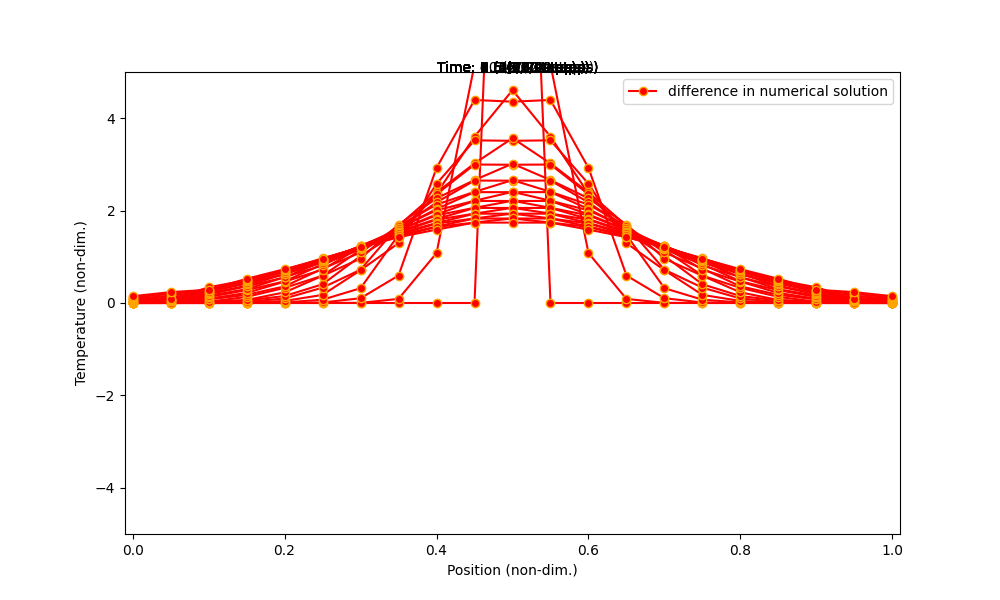

In [25]:
plt.close()
# Number of time steps
numsteps = 20

# Time step and spatial step
f = 0.5

# solve for given tau, h. NumSteps is used for visualisation
x, temp0, temp_an_array, temp_numeric, time = diffusion_ftcs(f)

#-------------------------------------------------------------------------------
# Plot the results as an animation

%matplotlib widget 
# This enables interactive mode; uncomment and run the following line to go back to static:
# %matplotlib inline
    
# Set up figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('t')
ax.set_ylabel('x')

# Plot initial profile
# ax.plot(x, temp0, '-', color='b', linewidth=1.5, label='Initial profile')

# Plot the solutions interactively
artists = []

for i in range(numsteps + 1):
    ax.set(xlim=[-0.01,1.01], ylim=[-5,5])
    diff_label = 'difference in numerical solution' if i == 0 else None

    diff_plot, = ax.plot(x, np.abs(temp_an_array[i, :] - temp_numeric[i, :]), 'ro-', markeredgecolor='orange', label=diff_label)
    
    title = ax.text(0.4, 5, f'Time: {i*f:.2g} ({i}/{numsteps} steps)')
    
    artists.append([diff_plot, title])

ani = animation.ArtistAnimation(fig=fig, artists=artists, interval=300, repeat=False)

ax.set_xlabel('Position (non-dim.)')
ax.set_ylabel('Temperature (non-dim.)')
ax.legend();
plt.show()

*Your notes*

## <span style="color:red">Q2</span>

As explained in lectures, the stability of the method is dependent on the eigenvalues of the update matrix $\mathrm{A}$, which are defined by the discretisation and by the boundary conditions.

Write new code to do the following:

1. For each value of $f$ from 0 to 1 in steps of $0.05$, calculate the update matrix $\mathrm{A}$. *You already have the code to do this within `diffusion_ftcs`]*

2. For each $f$ value, use the `numpy` function, `np.linalg.eigvals()` (and the `np.max()` and `np.min()` functions) to calculate the following three quantities:

   2.1 The maximum eigenvalue, $\lambda_{\rm max}$, of $\mathrm{A}$;

   2.2 The minimum eigenvalue, $\lambda_{\rm min}$, of $\mathrm{A}$;

   2.3 The magnitude of the dominant eigenvalue, $|\lambda_{\rm dom}|$, (the eigenvalue with the largest magnitude).

3. Plot $\lambda_{\rm min}$, $\lambda_{\rm max}$, and $|\lambda_{\rm dom}|$ as functions of $f$, on one graph, clearly showing individual plotting points using markers (and connecting points using a line).

Produce a single plot with your results, and upload an image of your plot (as a .png or .jpg file).

In [4]:
# include your script here

def diffusion_ftcs(f, h=0.05, kappa=1, numsteps=20):
    # Solve the 1-D diffusion equation for an initial spike profile
    # with Dirichlet conditions using FTCS, in a matrix formulation

    # Calculate the ratio tau/(th/2), where th is the approximate diffusion
    # time for one spatial step h

    tau = f * h**2 / kappa

    # Column vector of x values
    x = np.arange(0, 1 + h, h).reshape(-1, 1)
    L = len(x)

    # Construct the matrix D associated with the second spatial
    # derivative and the boundary conditions
    D = -2 * np.eye(L)
    D = D + np.diag(np.ones(L-1), 1) + np.diag(np.ones(L-1), -1)
    D = kappa * tau * D / h**2

    # Impose the Dirichlet boundary conditions
    D[0, :] = np.zeros(L)
    D[L-1, :] = np.zeros(L)

    # Construct the update matrix
    A = np.eye(L) + D

    # compute eigenvalues
    indices = np.arange(1, L+1, 1)
    eigenvalues = 1-4*f*np.sin(np.pi/2 * (indices-1)/(L-1))**2
    print(eigenvalues)

    # Initial conditions, temp0: a spike at x = 1/2
    temp0 = np.zeros((L, 1))
    # Find the index closest to x = 0.5
    idx = np.abs(x - 0.5).argmin()
    temp0[idx] = 1/h
    temp = temp0.copy()  # temp updates across the run

    # Record T(x,t) matrix for visualization
    time = tau * np.arange(numsteps + 1)
    temp_xt = np.zeros((numsteps + 1, L))
    temp_xt[0, :] = temp.flatten()
    
    # Create arrays to store analytical solutions at each step
    temp_an_array = np.zeros((numsteps + 1,L))

    #-------------------------------------------------------------------------------
    # March forwards in time, FTCS style!
    for n in range(numsteps):
        # Update the temperature profile
        temp = A @ temp # matrix multiplication

        # Recalculate the profile for the (approximate) analytic solution
        sig = np.sqrt(2 * kappa * time[n+1])
        temp_an = np.exp(-((x - 0.5)**2) / (2 * sig**2)) / (np.sqrt(2 * np.pi) * sig)
        
        # Store the analytical solution for this step
        temp_an_array[n+1, :] = temp_an.flatten()

        # Record T(x,t) matrix for visualization
        temp_xt[n+1, :] = temp.flatten()
        
    return x, temp0, temp_an_array, temp_xt, time


In [5]:
def get_update_matrix(f, h=0.05, kappa=1):
    tau = f * h**2 / kappa

    # Column vector of x values
    x = np.arange(0, 1 + h, h).reshape(-1, 1)
    L = len(x)

    # Construct the matrix D associated with the second spatial
    # derivative and the boundary conditions
    D = -2 * np.eye(L)
    D = D + np.diag(np.ones(L-1), 1) + np.diag(np.ones(L-1), -1)
    D = kappa * tau * D / h**2

    # Impose the Dirichlet boundary conditions
    D[0, :] = np.zeros(L)
    D[L-1, :] = np.zeros(L)

    # Construct the update matrix
    A = np.eye(L) + D

    return A

def get_eigenvalues(f, h=0.05):

    x = np.arange(0, 1 + h, h)
    L = len(x)

    indices = np.arange(1, L+1, 1)
    eigenvalues = 1-4*f*np.sin(np.pi/2 * (indices-1)/(L-1))**2
    eigenvalues[-1] = 1
    
    return eigenvalues

def get_eigenvalues_linalg(A):
    return np.array([np.linalg.eigvals(A_i) for A_i in A])


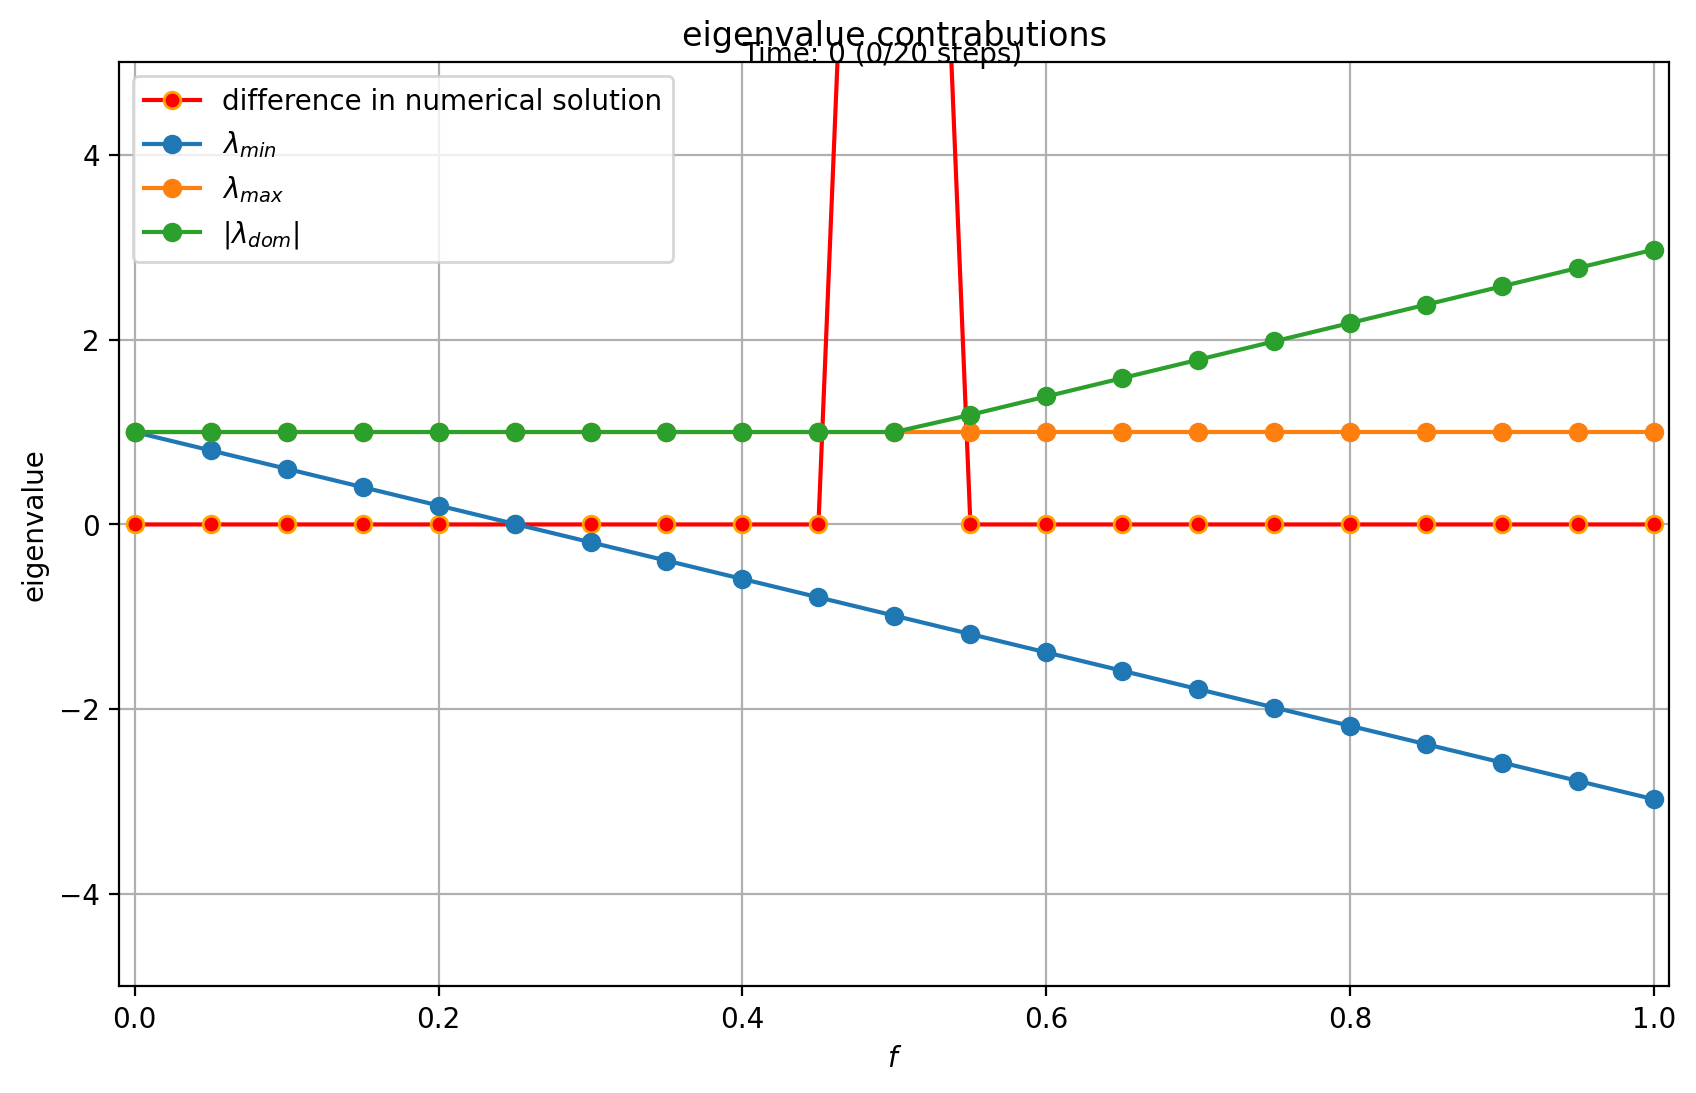

In [6]:
%matplotlib inline

f_vec = np.arange(0, 1.05, 0.05)
h = 0.05
kappa = 1

A_vec = np.array([get_update_matrix(f, h, kappa) for f in f_vec])
eigvals_vec = get_eigenvalues_linalg(A_vec)

lambda_min = np.min(eigvals_vec, axis=1)
lambda_max = np.max(eigvals_vec, axis=1)
lambda_dom = np.max(np.abs(eigvals_vec), axis=1)

plt.plot(f_vec, lambda_min, "-o", label=r"$\lambda_{min}$")
plt.plot(f_vec, lambda_max, "-o", label=r"$\lambda_{max}$")
plt.plot(f_vec, lambda_dom, "-o", label=r"$|\lambda_{dom}|$")

plt.xlabel(r"$f$")
plt.ylabel("eigenvalue")
plt.legend()
plt.grid(True)

plt.title(r"eigenvalue contrabutions")

plt.savefig("fig1.png")
plt.show()

*Your notes:*

## <span style="color:red">Q3</span>

<p>As a way to understand the four types of behavior identified in Question 1, we can consider power iteration applied to the initial temperature profile, \({\bf T}^{[0]}\), in terms of an expansion in the eigenvectors of the update matrix, \(\mathrm{A}\):</p>
<p>\({\bf T}^{[0]} = \sum_{i=1}^L C_i{\bf T}^{(i)}\), for constants \(C_i\) and where \({\bf T}^{(i)}\) are the eigenvectors of \(\mathrm{A}\).</p>
<p>Then, after \(m\) power iterations, \({\bf T}^{[m]} = \mathrm{A}^{m}{\bf T}^{[0]} = \sum_{i=1}^{L}C_i\lambda_i^m{\bf T}^{(i)}\), where \({\bf T}^{[j]}\) is the temperature profile at iteration \(j\).</p>
<p>Categorize the numerical behavior of the FTCS numerical scheme across the four relevant ranges of \(f\), and the corresponding conditions on the set of eigenvalues, \(\lambda_i\).</p>

*Your notes:*

## <span style="color:red">Q4</span>

<p>For each of the four categories above, briefly explain why each range of \(\lambda_i\) yields each qualitative type of algorithmic behavior.</p>

*Your notes:*

# Part II: Solving a different initial value/boundary value problem

These questions involve modifying the diffusion_ftcs.ipynb code to solve a different diffusion problem

Consider the 1-D heat diffusion initial value problem with an initially zero temperature profile: $T(x,0)=0 \quad \text{for}\quad  0<x<1,$ and with boundary conditions $T(0,t)=T(1,t)=1$ for all $t$.

This initial value problem (IVP) describes a thermally conducting rod at some temperature, which suddenly (at time $t=0$) has the temperature of the ends raised (and maintained) at a second, higher temperature.


## <span style="color:red">Q5</span>

<p>The update matrix, \(\mathrm{A}\), for the FTCS scheme for 1-D diffusion with Dirichlet boundary conditions is given by</p>
<p>&nbsp;</p>
<p><img style="display: block; margin-left: auto; margin-right: auto;" src="https://quiz-api-production-s3-uploads-4mqunb7g4o7t.s3.ap-southeast-2.amazonaws.com/item_media/d1c558c5-d73b-4635-b0b0-780a8e6e4c7a/e6494c67-77cd-4ac5-bb84-b5339fdfeff8" alt="" width="419" height="168" /></p>
<p>&nbsp;</p>
<p>The top row and bottom rows in the \(L\times L\) update matrix impose which of the following conditions?</p>

*Your notes*

## <span style="color:red">Q6</span>

<p>Consider solving the different IVP described.<br /><br />In modifying <code>diffusion_ftcs</code> to solve this new problem, is it necessary to change the update matrix?</p>

## <span style="color:red">Q7</span>

<p>Modify <code>diffusion_ftcs</code> to solve the new IVP.</p>
<p>Use a spatial step \(h=0.05\), a thermal conductivity \(\kappa=5,\) and a time step \(\tau\) chosen so that \(f = \kappa\tau/h^2 = 0.25\).</p>
<p>Run the code for a large number of time steps (say 1000), until an approximate <em>equilibrium</em> is reached (i.e., the temperature profile is not changing substantially).</p>
<p>(If you're having computational issues, you may speed up the calculation by reducing the frequency of plotting the temperature profile less frequently, e.g., once every 10-50 iterations).</p>
<p>What is the equilibrium solution?</p>


In [91]:
# Add your code here:

def diffusion_ftcs(f, h=0.05, kappa=1, numsteps=20):
    # Solve the 1-D diffusion equation for an initial spike profile
    # with Dirichlet conditions using FTCS, in a matrix formulation

    # Calculate the ratio tau/(th/2), where th is the approximate diffusion
    # time for one spatial step h

    tau = f * h**2 / kappa

    # Column vector of x values
    x = np.arange(0, 1 + h, h).reshape(-1, 1)
    L = len(x)

    # Construct the matrix D associated with the second spatial
    # derivative and the boundary conditions
    D = -2 * np.eye(L)
    D = D + np.diag(np.ones(L-1), 1) + np.diag(np.ones(L-1), -1)
    D = kappa * tau * D / h**2

    # Impose the Dirichlet boundary conditions
    D[0, :] = np.zeros(L)
    D[L-1, :] = np.zeros(L)

    # Construct the update matrix
    A = np.eye(L) + D

    # # compute eigenvalues
    # indices = np.arange(1, L+1, 1)
    # eigenvalues = 1-4*f*np.sin(np.pi/2 * (indices-1)/(L-1))**2

    # Initial conditions, temp0: 0 unless boundaries, then 1
    temp0 = np.zeros((L, 1))
    temp0[0] = 0
    temp0[-1] = 1

    temp = temp0.copy()  # temp updates across the run

    # Record T(x,t) matrix for visualization
    time = tau * np.arange(numsteps + 1)
    temp_xt = np.zeros((numsteps + 1, L))
    temp_xt[0, :] = temp.flatten()

    #-------------------------------------------------------------------------------
    # March forwards in time, FTCS style!
    for n in range(numsteps):
        # Update the temperature profile
        temp = A @ temp # matrix multiplicatio

        # Record T(x,t) matrix for visualization
        temp_xt[n+1, :] = temp.flatten()
        
    return x, temp0, temp_xt, time


In [92]:
%matplotlib inline

f = 0.25
h = 0.05
kappa = 5
numsteps=1000

x, temp0, temp_numeric, time = diffusion_ftcs(f, h, kappa, numsteps)

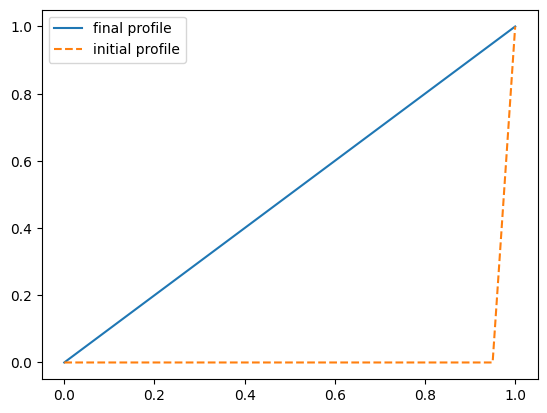

In [94]:
# %matplotlib inline

f = 0.25
h = 0.05
kappa = 5
numsteps=10000
tau = f * h**2 / kappa

x, temp0, temp_numeric, time = diffusion_ftcs(f, h, kappa, numsteps)

%matplotlib inline 
# This enables interactive mode; uncomment and run the following line to go back to static:
# %matplotlib inline
    
plt.plot(x, temp_numeric[-1, :], label="final profile")
plt.plot(x, temp_numeric[0, :], "--", label="initial profile")
plt.legend()
plt.savefig("lab4_2.png")
plt.show()

In [82]:
plt.close()

*Your notes:*

## <span style="color:red">Q8</span>

<p>Provide an analytic explanation for the equilibrium found numerically in Question 6:</p>
<ol>
<li>Setting \(\partial T/\partial t = 0\) in the 1-D diffusion PDE gives a simple ODE describing the equilibrium situation: \[\frac{d^2T_{\rm eq}}{dx^2}=0,\] where \(T_{\rm eq}(x)\) is the equilibrium temperature profile.</li>
<li>By integrating this ODE analytically, and imposing the boundary conditions \(T(0,t) = T(1,t) = 1\) for all \(t\), obtain an analytic expression for the equilibrium temperature profile.&nbsp;</li>
</ol>
<p><strong>Briefly summarize your steps..</strong></p>

## <span style="color:red">Q9</span>

<p>Consider the case that the temperature profile is again&nbsp;zero initially for \(0&lt;x&lt;1\) but the BCs are changed to \[T(0,t)=0\quad \text{and}\quad T(1,t)=1\]&nbsp;for all \(t.\)</p>
<p>&nbsp;</p>
<p>Following the same reasoning as Question 7, make a prediction about what the equilibrium solution will look like.</p>
<p>&nbsp;</p>
<p>Modify the initial conditions from your code from Question 6 and run it to confirm your prediction.<br /><br /><strong>Upload a clear image of your FINAL EQUILIBRIUM TEMPERATURE PROFILE plot.</strong></p>